In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler

In [2]:
ili_df = pd.read_csv("../../backend/data/ili/national_illness.csv", parse_dates=["date"])
ili_df.head()

,date,% WEIGHTED ILI,%UNWEIGHTED ILI,AGE 0-4,AGE 5-24,ILITOTAL,NUM. OF PROVIDERS,OT
0,2002-01-01,1.22262,1.16668,582,805,2060,754,176569
1,2002-01-08,1.33344,1.21650,683,872,2267,785,186355
2,2002-01-15,1.31929,1.13057,642,878,2176,831,192469
3,2002-01-22,1.49484,1.25246,728,1045,2599,863,207512
4,2002-01-29,1.47195,1.30237,823,1189,2907,909,223208


In [3]:
ili_df.shape

(966, 8)

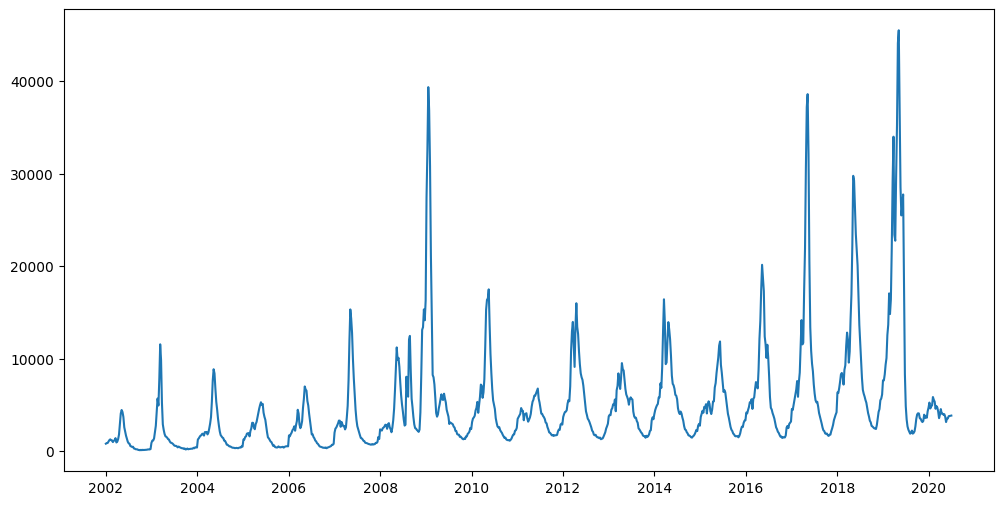

In [4]:
plt.figure(figsize=(12, 6))
plt.plot(ili_df['date'], ili_df['AGE 5-24'], label='ILI Cases')

In [5]:
ili_df.head(1)

,date,% WEIGHTED ILI,%UNWEIGHTED ILI,AGE 0-4,AGE 5-24,ILITOTAL,NUM. OF PROVIDERS,OT
0,2002-01-01,1.22262,1.16668,582,805,2060,754,176569


In [6]:
# aggregate weekly data to monthly data
monthly_ili_df = ili_df.resample('M', on='date').sum()
monthly_ili_df.head()

/tmp/ipykernel_11907/2741556773.py:2: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_ili_df = ili_df.resample('M', on='date').sum()


,% WEIGHTED ILI,%UNWEIGHTED ILI,AGE 0-4,AGE 5-24,ILITOTAL,NUM. OF PROVIDERS,OT
date,,,,,,,
2002-01-31,6.84214,6.06858,3458,4789,12009,4142,986113
2002-02-28,6.09499,5.55026,3374,4589,11998,3693,865798
2002-03-31,7.80402,6.07215,3527,4637,12279,3638,838680
2002-04-30,11.70575,10.59433,6034,11175,23968,4518,1119791
2002-05-31,11.94453,11.49949,6204,14943,28265,3520,982200


In [7]:
monthly_ili_df.shape

(222, 7)

In [8]:
222//12

18

In [9]:
monthly_ili_df.to_csv("ILI_cases_monthly.csv", index=True)

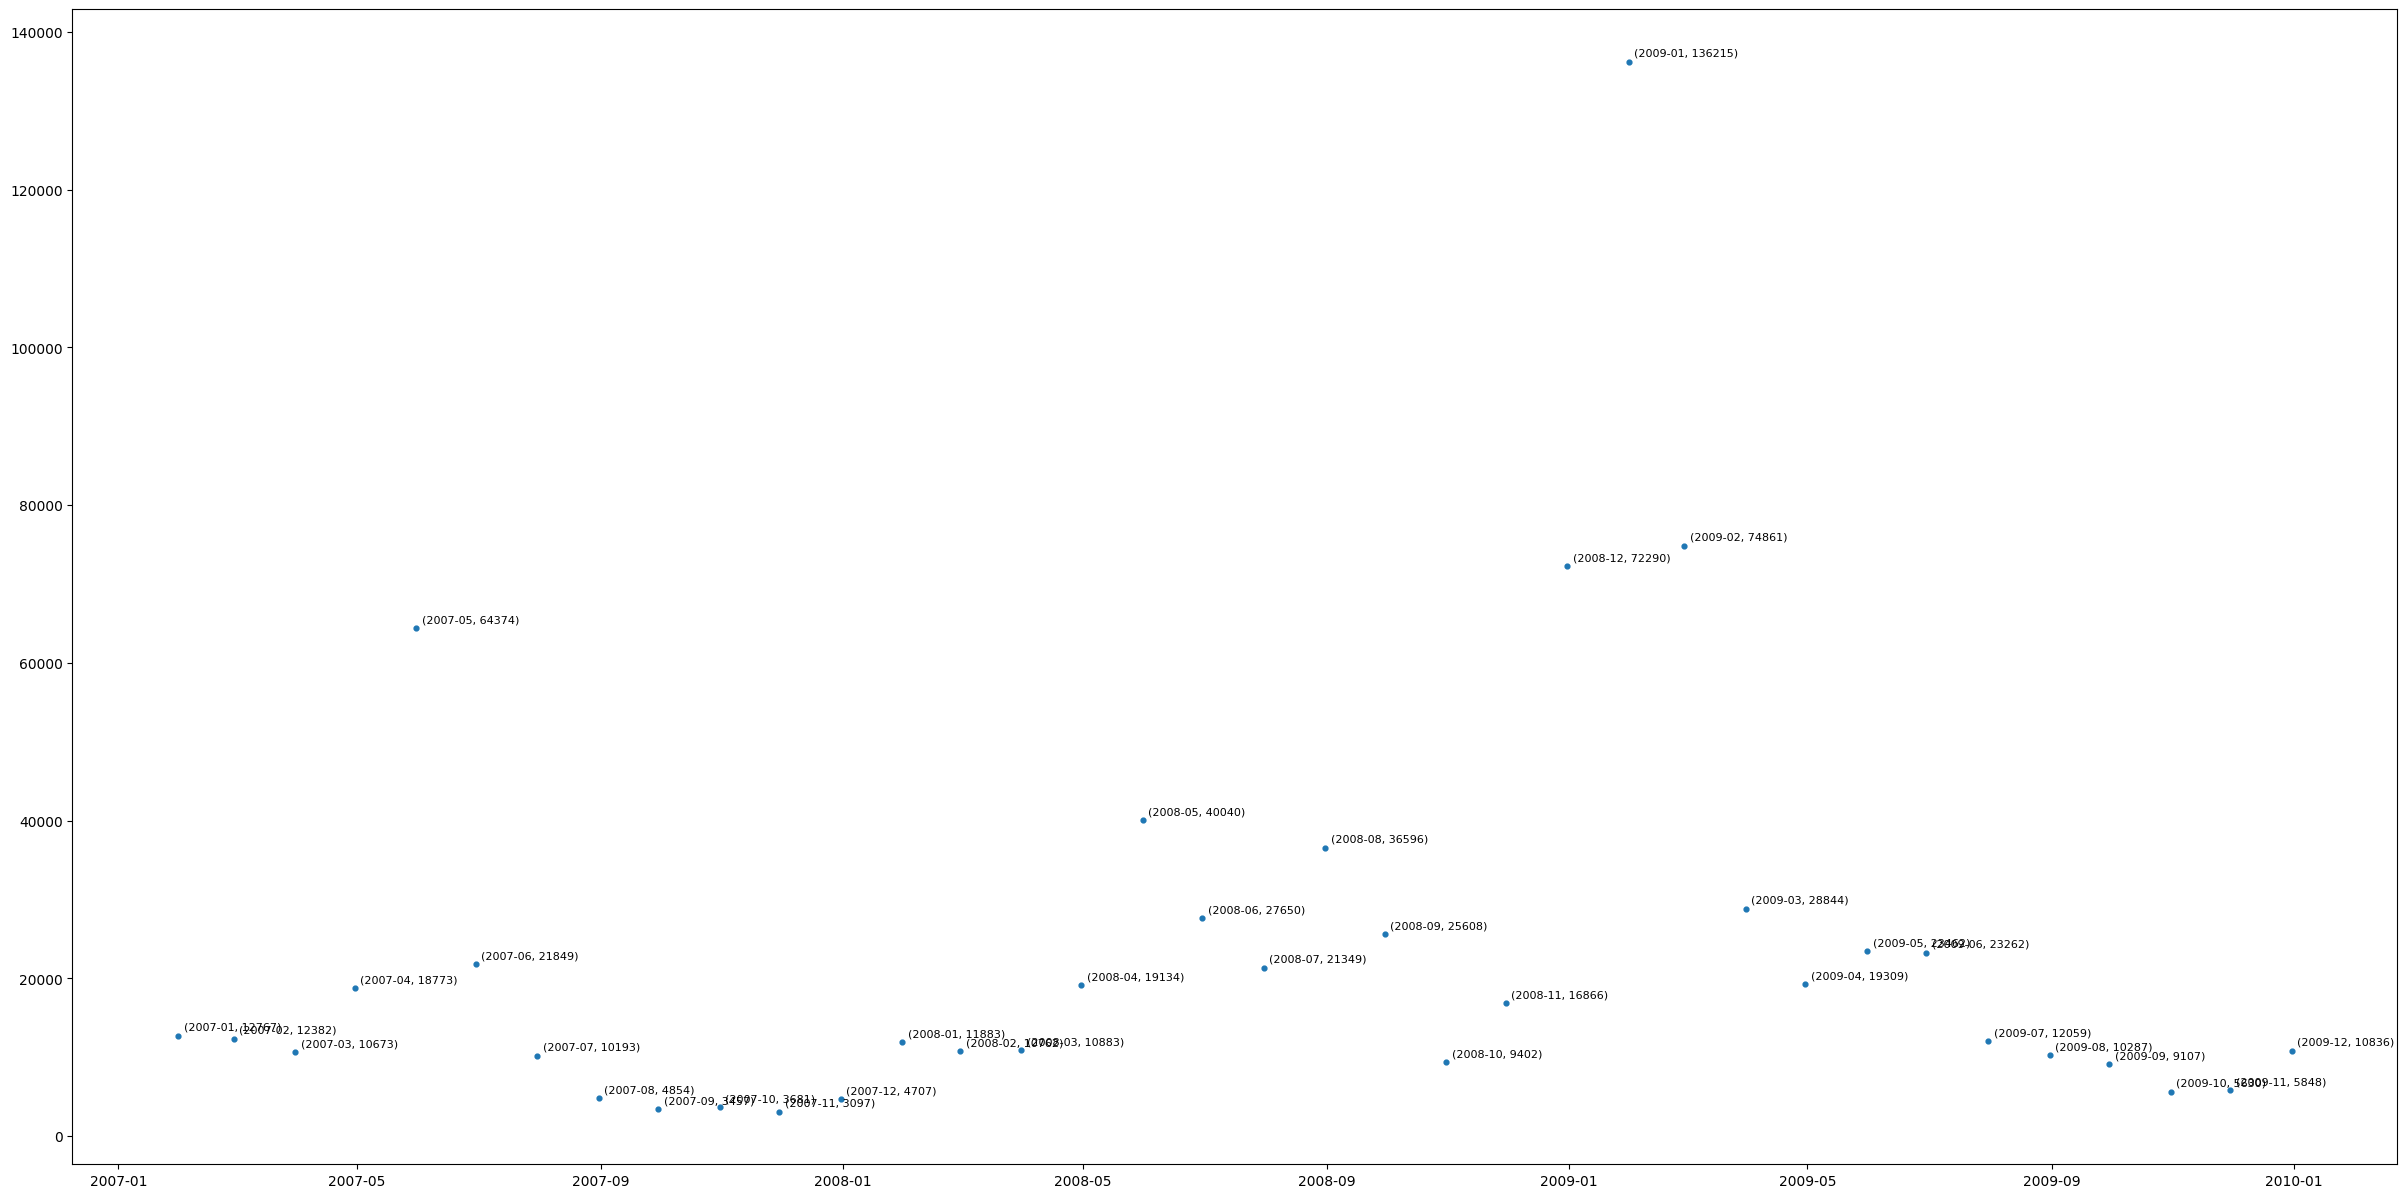

In [10]:
plt.figure(figsize=(30, 15))
x = monthly_ili_df.index[5*12:8*12]
y = monthly_ili_df['AGE 5-24'][5*12:8*12]
plt.scatter(x, y, s=12)

for xi, yi in zip(x, y):
    plt.annotate(
        f'({xi:%Y-%m}, {yi:.0f})',
        (xi, yi),
        textcoords='offset points',
        xytext=(4, 4),
        fontsize=8,
    )

# plt.plot(monthly_ili_df['AGE 5-24'][1*12:3*12], label='ILI Cases')
# plt.legend()
plt.savefig("monthly_ili_plot.png", dpi=300, bbox_inches="tight")


In [11]:
# find peaks in the monthly ILI cases for age group 5-24
from scipy.signal import find_peaks


peaks,_ = find_peaks(monthly_ili_df['AGE 5-24'].values, distance=3)
peaks

array([  4,  14,  28,  40,  46,  52,  60,  64,  69,  72,  76,  79,  84,
        88, 100, 112, 123, 129, 132, 135, 138, 147, 158, 161, 172, 184,
       192, 196, 207, 215, 218])

In [13]:
indices = monthly_ili_df.index[peaks]
indices

DatetimeIndex(['2002-05-31', '2003-03-31', '2004-05-31', '2005-05-31',
               '2005-11-30', '2006-05-31', '2007-01-31', '2007-05-31',
               '2007-10-31', '2008-01-31', '2008-05-31', '2008-08-31',
               '2009-01-31', '2009-05-31', '2010-05-31', '2011-05-31',
               '2012-04-30', '2012-10-31', '2013-01-31', '2013-04-30',
               '2013-07-31', '2014-04-30', '2015-03-31', '2015-06-30',
               '2016-05-31', '2017-05-31', '2018-01-31', '2018-05-31',
               '2019-04-30', '2019-12-31', '2020-03-31'],
              dtype='datetime64[ns]', name='date', freq=None)

In [14]:
# extract month form the datetimeIndex
months = indices.month
months

Index([ 5,  3,  5,  5, 11,  5,  1,  5, 10,  1,  5,  8,  1,  5,  5,  5,  4, 10,
        1,  4,  7,  4,  3,  6,  5,  5,  1,  5,  4, 12,  3],
      dtype='int32', name='date')

In [15]:
from collections import Counter
month_counts = Counter(months)
month_counts

Counter({5: 12, 1: 5, 4: 4, 3: 3, 10: 2, 11: 1, 8: 1, 7: 1, 6: 1, 12: 1})

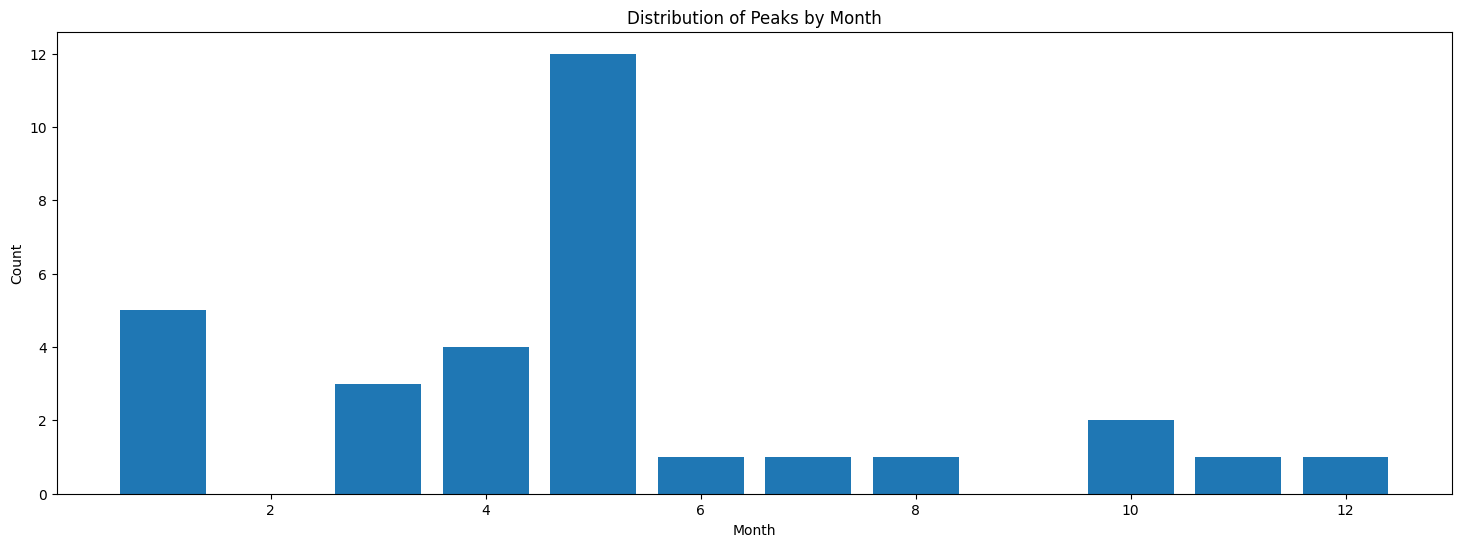

In [17]:
plt.figure(figsize=(18, 6))
plt.bar(month_counts.keys(), month_counts.values())
plt.xlabel('Month')
plt.ylabel('Count')
plt.title('Distribution of Peaks by Month')
plt.show()

### Only using data of 25 days

In [ ]:
df = ili_df.iloc[:18*52, 1:7]
df_raw = df.copy()
df.head()

,% WEIGHTED ILI,%UNWEIGHTED ILI,AGE 0-4,AGE 5-24,ILITOTAL,NUM. OF PROVIDERS
0,1.22262,1.16668,582,805,2060,754
1,1.33344,1.21650,683,872,2267,785
2,1.31929,1.13057,642,878,2176,831
3,1.49484,1.25246,728,1045,2599,863
4,1.47195,1.30237,823,1189,2907,909


In [ ]:
scaler = StandardScaler()
df[df.columns] = scaler.fit_transform(df)
df.head()

,% WEIGHTED ILI,%UNWEIGHTED ILI,AGE 0-4,AGE 5-24,ILITOTAL,NUM. OF PROVIDERS
0,-0.477919,-0.529271,-0.900063,-0.694778,-0.746084,-1.287692
1,-0.396317,-0.491612,-0.868483,-0.683690,-0.732475,-1.237858
2,-0.406736,-0.556567,-0.881303,-0.682698,-0.738458,-1.163910
3,-0.277469,-0.464430,-0.854413,-0.655062,-0.710648,-1.112468
4,-0.294324,-0.426703,-0.824708,-0.631232,-0.690398,-1.038521


In [ ]:
df['date'] = ili_df['date'].iloc[:18*52]

In [ ]:
df.head()

,% WEIGHTED ILI,%UNWEIGHTED ILI,AGE 0-4,AGE 5-24,ILITOTAL,NUM. OF PROVIDERS,date
0,-0.477919,-0.529271,-0.900063,-0.694778,-0.746084,-1.287692,2002-01-01 00:00:00
1,-0.396317,-0.491612,-0.868483,-0.683690,-0.732475,-1.237858,2002-01-08 00:00:00
2,-0.406736,-0.556567,-0.881303,-0.682698,-0.738458,-1.163910,2002-01-15 00:00:00
3,-0.277469,-0.464430,-0.854413,-0.655062,-0.710648,-1.112468,2002-01-22 00:00:00
4,-0.294324,-0.426703,-0.824708,-0.631232,-0.690398,-1.038521,2002-01-29 00:00:00


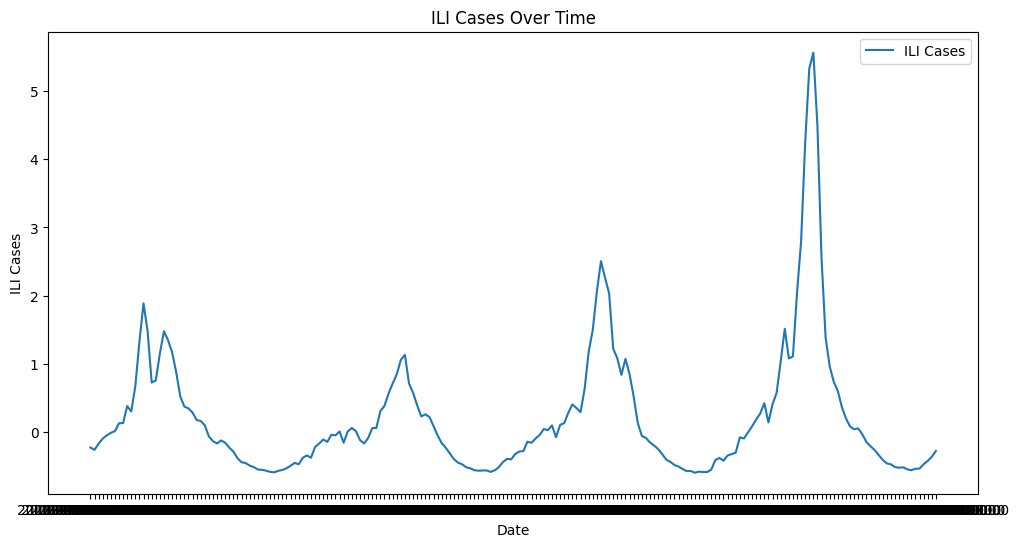

In [ ]:
plt.figure(figsize=(12, 6))
plt.plot(df['date'][12*52:16*52], df['AGE 5-24'][12*52:16*52], label='ILI Cases')
plt.xlabel('Date')
plt.ylabel('ILI Cases')
plt.title('ILI Cases Over Time')
plt.legend()
plt.show()

### Smoothing using rolling mean

In [ ]:
# # make each numeric column smooth by rolling mean
# numeric_cols = df.select_dtypes(include='number').columns
# df[numeric_cols] = df[numeric_cols].rolling(window=5, min_periods=1).mean()

# for col in ['pm2.5', 'DEWP', 'TEMP', 'PRES', 'Iws']:
#     plt.figure(figsize=(12, 4))
#     plt.plot(df[col][:10000])
#     plt.title(f"{col} over time (smoothed)")

In [ ]:
import math

SPLIT_RATIO = 0.8
TOTAL_POINTS = len(df)
PERIOD = 18
TRAIN_DAYS = math.ceil(PERIOD * SPLIT_RATIO)
TEST_DAYS = PERIOD - TRAIN_DAYS
TIME = TOTAL_POINTS // PERIOD
FEATURES = len(df.columns)
print(f"Tensor dimensions: {PERIOD} x {TIME} x {FEATURES}")
print(f"Train days: {TRAIN_DAYS}, Test days: {TEST_DAYS}")

Tensor dimensions: 18 x 53 x 6
Train days: 15, Test days: 3


In [ ]:
# data = df[['pm2.5', 'DEWP', 'TEMP', 'PRES', 'Iws']][:PERIOD*TIME].values
# data = df[['DEWP', 'TEMP', 'PRES', 'Iws']][:PERIOD*TIME].values
data = df[:PERIOD*TIME].values
tensor = data.reshape(PERIOD, TIME, FEATURES)
tensor.shape

(18, 53, 6)

In [ ]:
train_tensor = tensor[:TRAIN_DAYS, :, :]
test_tensor = tensor[TRAIN_DAYS:TRAIN_DAYS+TEST_DAYS, :, :]
print(f"Train tensor shape: {train_tensor.shape}")
print(f"Test tensor shape: {test_tensor.shape}")

Train tensor shape: (15, 53, 6)
Test tensor shape: (3, 53, 6)


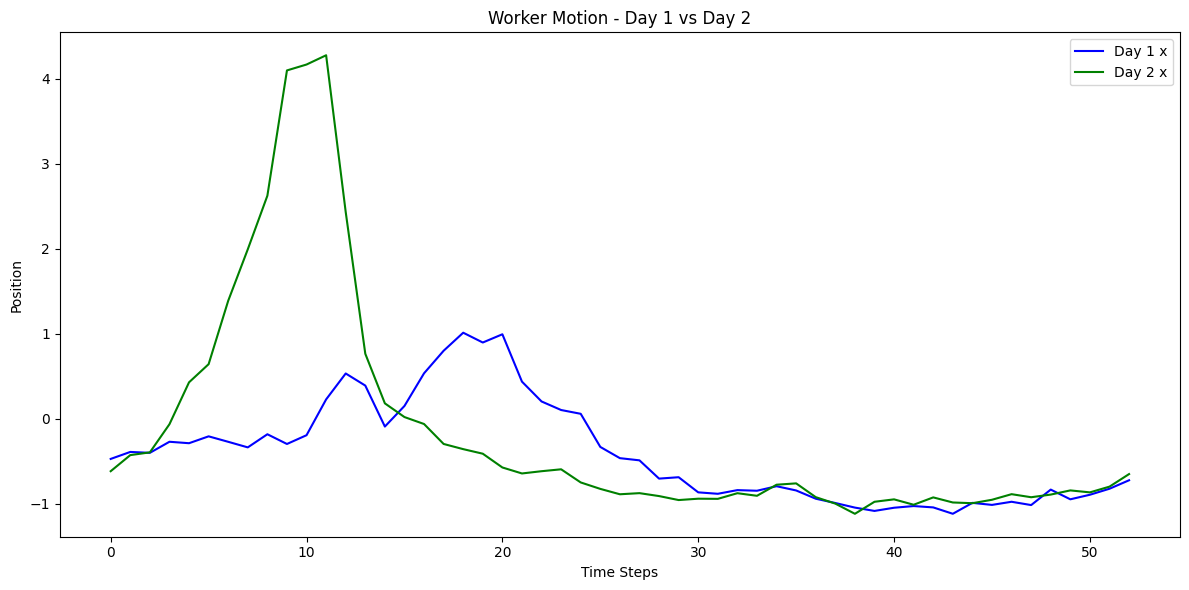

In [ ]:
train_day_1 = tensor[0, :, :]
train_day_2 = tensor[1, :, :]

# day 1,3 merged
plt.figure(figsize=(12, 6))
plt.plot(train_day_1[:, 0], label='Day 1 x', color='blue')
# plt.plot(train_day_1[:, 1], label='Day 1 y', color='blue')
plt.plot(train_day_2[:, 0], label='Day 2 x', color='green')
# plt.plot(train_day_2[:, 1], label='Day 2 y', color='green')
plt.title('Worker Motion - Day 1 vs Day 2')
plt.xlabel('Time Steps')
plt.ylabel('Position')
plt.legend()
plt.tight_layout()
plt.show()

### Tensor Decomposition

In [ ]:
from tensorly.decomposition import parafac

R = 2
weights, factors = parafac(train_tensor, rank=R, normalize_factors=True)

day_factors, time_factors, feature_factors = factors
print(f"Day factors shape: {day_factors.shape}")
print(f"Time factors shape: {time_factors.shape}")
print(f"Feature factors shape: {feature_factors.shape}")

Day factors shape: (15, 2)
Time factors shape: (53, 2)
Feature factors shape: (6, 2)


In [ ]:
from tensorly import cp_to_tensor

# Reconstruct the tensor
reconstructed_tensor = cp_to_tensor((weights, factors))

# Or without weights (if normalize_factors=True, weights contain the norms)
# reconstructed_tensor = cp_to_tensor(factors)  # this ignores weights

print(f"Original tensor shape: {train_tensor.shape}")
print(f"Reconstructed tensor shape: {reconstructed_tensor.shape}")

Original tensor shape: (15, 53, 6)
Reconstructed tensor shape: (15, 53, 6)


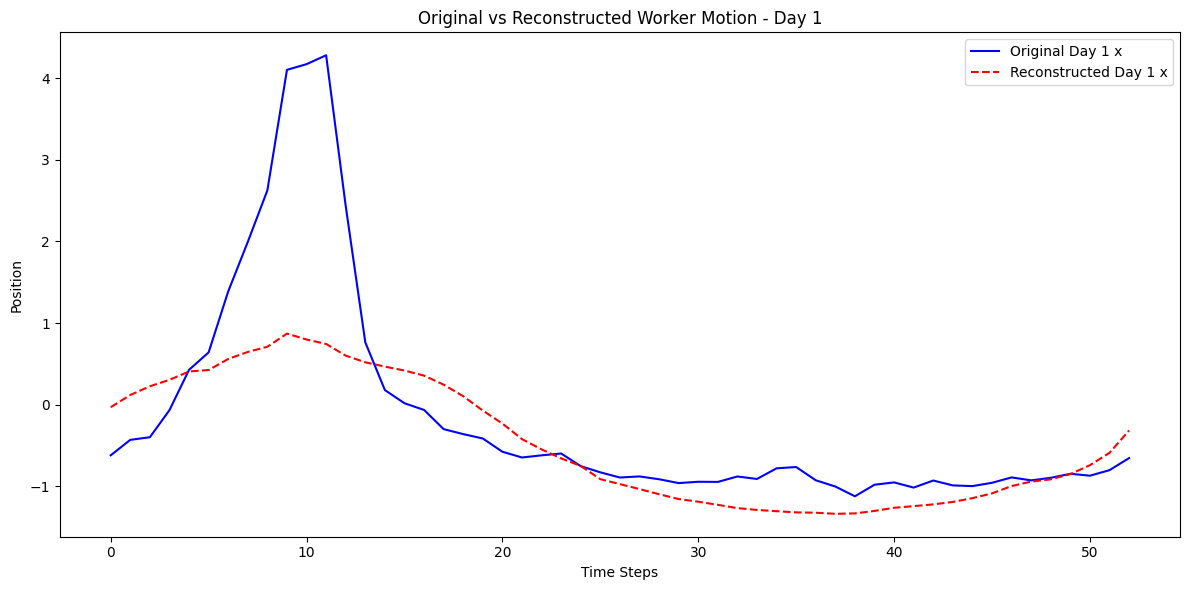

In [ ]:
train_day_1 = train_tensor[1, :, :]
train_day_1_reconstructed = reconstructed_tensor[1, :, :]

plt.figure(figsize=(12, 6))
plt.plot(train_day_1[:, 0], label='Original Day 1 x', color='blue')
# plt.plot(train_day_1[:, 1], label='Original Day 1 y', color='blue')
plt.plot(train_day_1_reconstructed[:, 0], label='Reconstructed Day 1 x', color='red', linestyle='dashed')
# plt.plot(train_day_1_reconstructed[:, 1], label='Reconstructed Day 1 y', color='red', linestyle='dashed')
plt.title('Original vs Reconstructed Worker Motion - Day 1')
plt.xlabel('Time Steps')
plt.ylabel('Position')
plt.legend()
plt.tight_layout()
plt.show()

### Tensor AR

In [ ]:
from statsmodels.tsa.ar_model import AutoReg
from statsmodels.tsa.statespace.sarimax import SARIMAX

forecast_day_factors = np.zeros((TEST_DAYS, R))
for r in range(R):
    series = day_factors[:, r]
    model = AutoReg(series, lags=1, old_names=False)
    # model = AutoReg(series, lags=7, old_names=False)
    # model = SARIMAX(series, order=(1,1,1), seasonal_order=(1,1,1,24))
    model_fit = model.fit()
    forecast = model_fit.forecast(steps=TEST_DAYS)
    forecast_day_factors[:, r] = forecast

# Reconstruct forecast tensor
forecast_tensor = np.zeros((TEST_DAYS, TIME, FEATURES))
for i in range(TEST_DAYS):
    for r in range(R):
        forecast_tensor[i, :, :] += weights[r] * np.outer(forecast_day_factors[i, r] * time_factors[:, r], feature_factors[:, r])

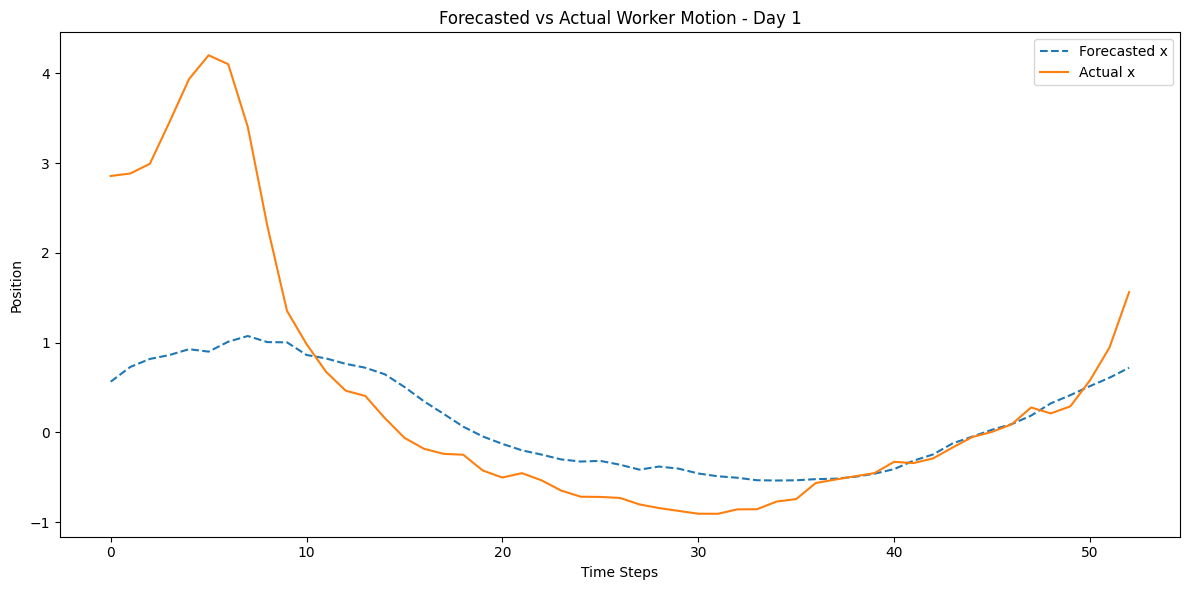

In [ ]:
forecasted_day_1 = forecast_tensor[0, :, :]

forecasted_day_1_x = forecasted_day_1[:, 0]
forecasted_day_1_y = forecasted_day_1[:, 1]

test_day_1 = tensor[TRAIN_DAYS, :, :]
real_of_forecast_day_1_x = test_day_1[:, 0]
real_of_forecast_day_1_y = test_day_1[:, 1]

# merge forecast and actual for day 1
plt.figure(figsize=(12, 6))
plt.plot(forecasted_day_1_x, label='Forecasted x', linestyle='--')
# plt.plot(forecasted_day_1_y, label='Forecasted y', linestyle='--')
# plt.plot(forecasted_day_1_x, label='Forecasted x')
# plt.plot(forecasted_day_1_y, label='Forecasted y')
plt.plot(real_of_forecast_day_1_x, label='Actual x')
# plt.plot(real_of_forecast_day_1_y, label='Actual y')
plt.title('Forecasted vs Actual Worker Motion - Day 1')
plt.xlabel('Time Steps')
plt.ylabel('Position')
plt.legend()
plt.tight_layout()
plt.show()

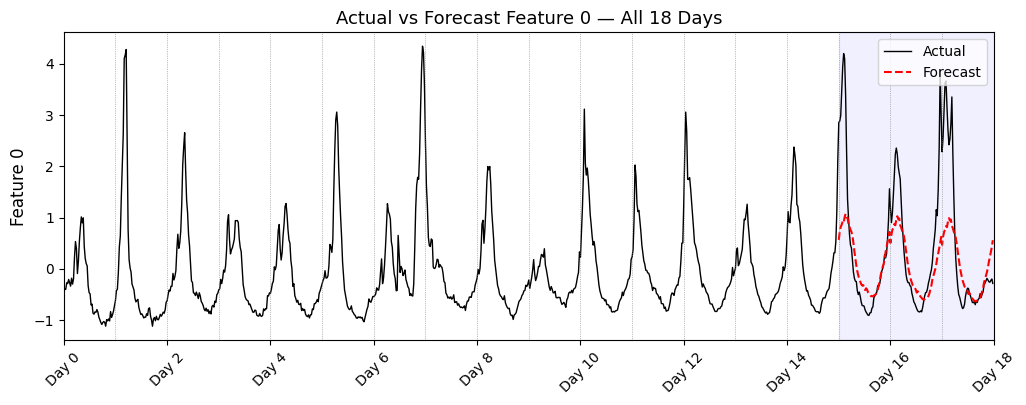

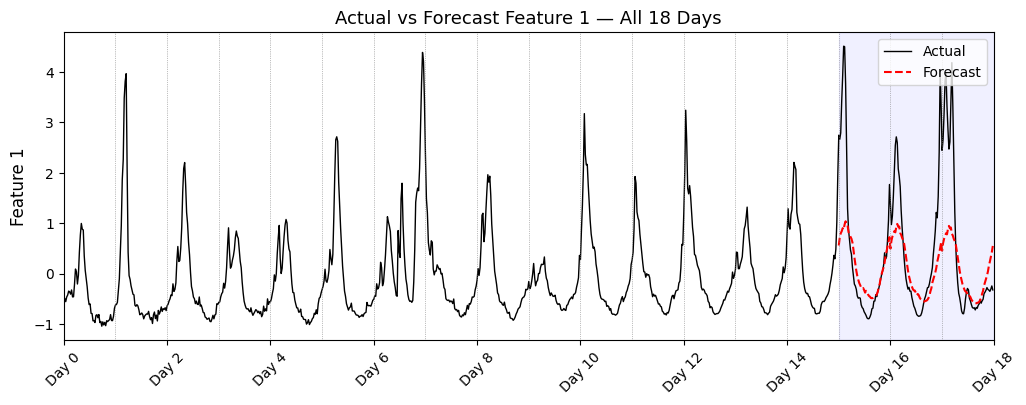

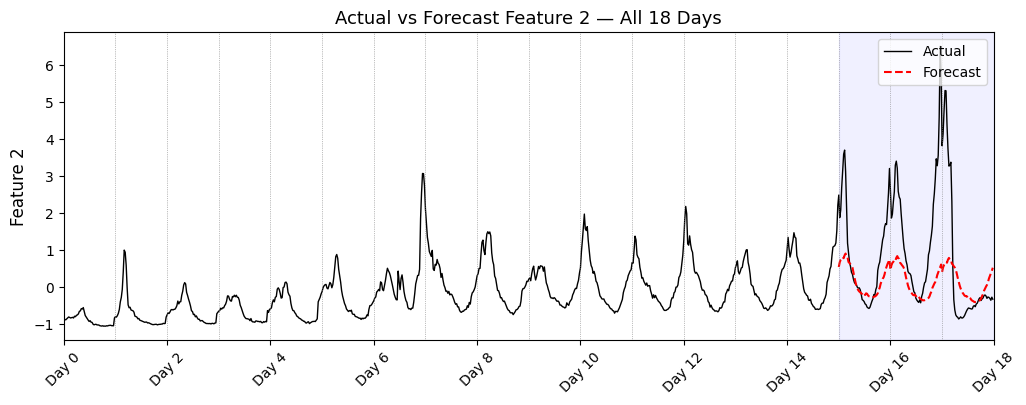

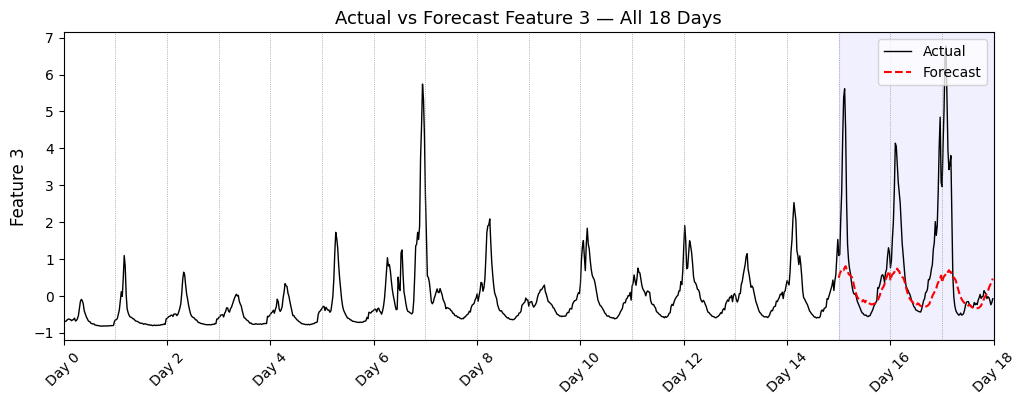

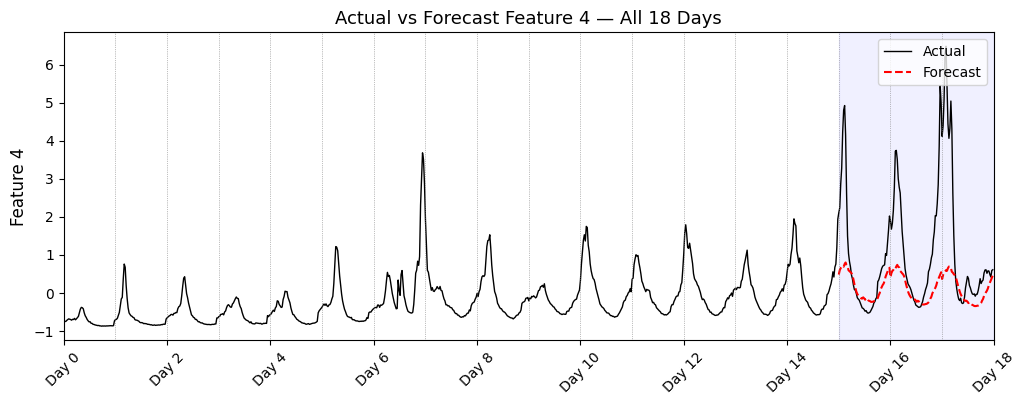

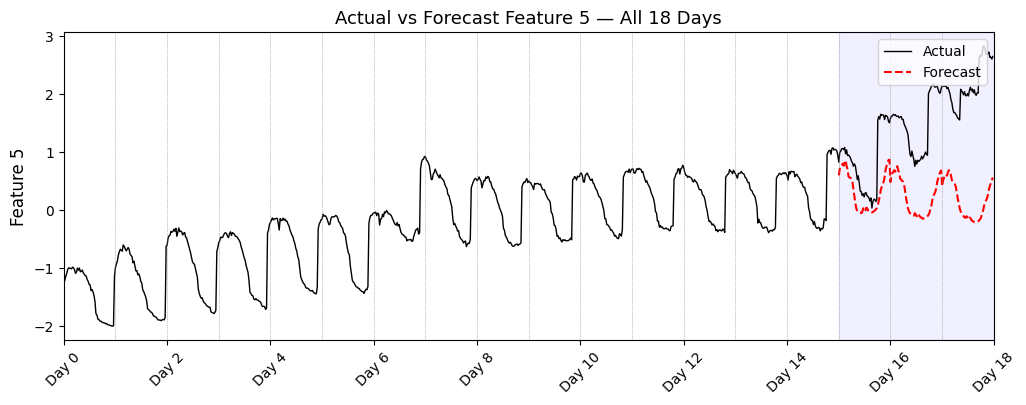

In [ ]:
# Flatten full tensor and forecast tensor into time series
full_series = tensor.reshape(-1, FEATURES)
# full_series = df_raw[['Temp', 'dummy']][:PERIOD*TIME].values.reshape(-1, FEATURES) 
forecast_series = forecast_tensor.reshape(-1, FEATURES)

T = PERIOD * TIME
x = np.arange(T)
forecast_start = TRAIN_DAYS * TIME
x_forecast = np.arange(forecast_start, forecast_start + TEST_DAYS * TIME)

for i in range(FEATURES):
    plt.figure(figsize=(12, 4))
    plt.plot(x, full_series[:, i], 'k-', lw=1, label='Actual')
    plt.plot(x_forecast, forecast_series[:, i], 'r--', lw=1.5, label='Forecast')
    for d in range(1, PERIOD + 1):
        plt.axvline(d * TIME, color='gray', ls=':', lw=0.5)
    plt.axvspan(forecast_start, T, alpha=0.06, color='blue')
    plt.xticks(np.arange(0, T + 1, 2 * TIME),
               [f'Day {d}' for d in range(0, PERIOD + 1, 2)], rotation=45)
    plt.xlim(0, T)
    plt.ylabel(f'Feature {i}', fontsize=12)
    plt.title(f'Actual vs Forecast Feature {i} — All {PERIOD} Days', fontsize=13)
    plt.legend(loc='upper right')

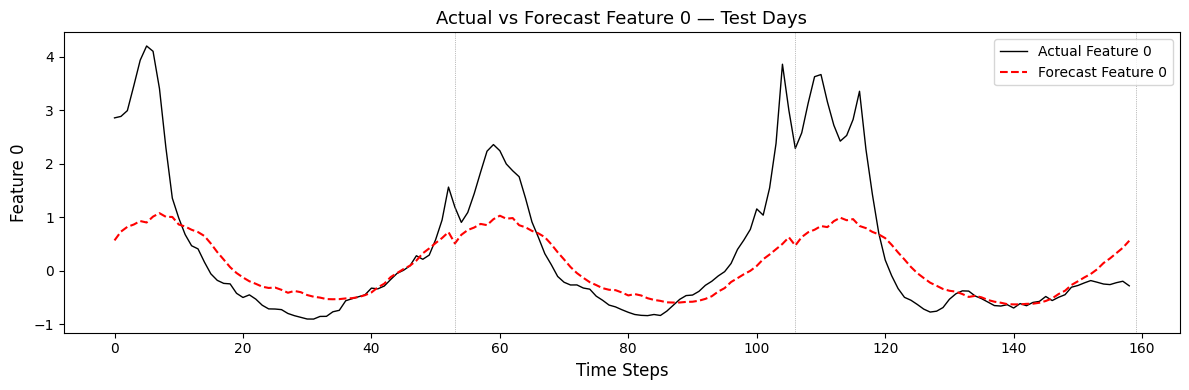

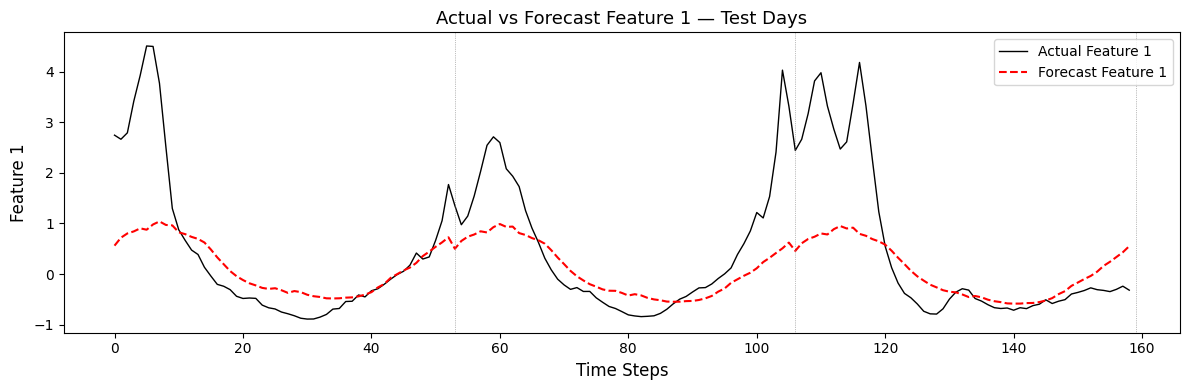

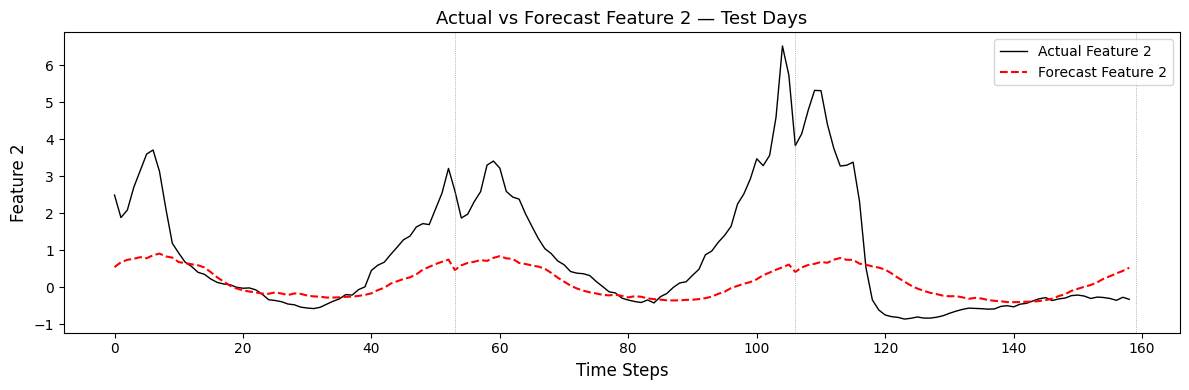

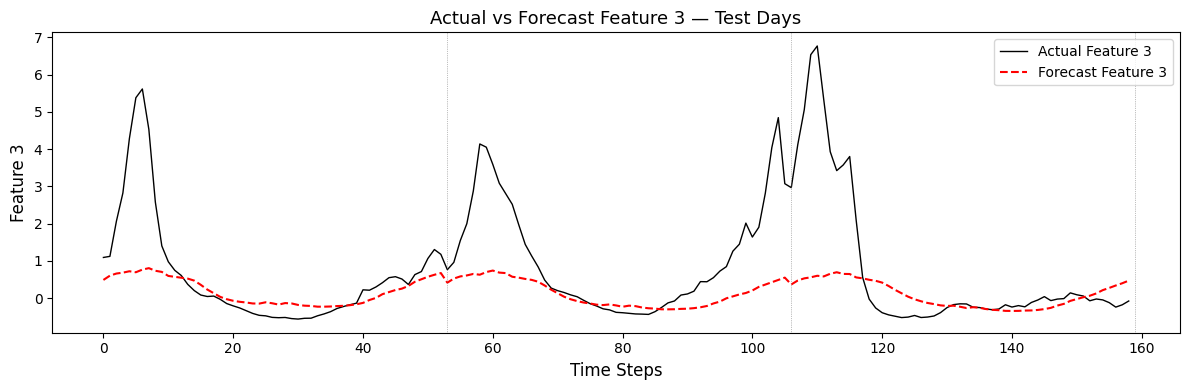

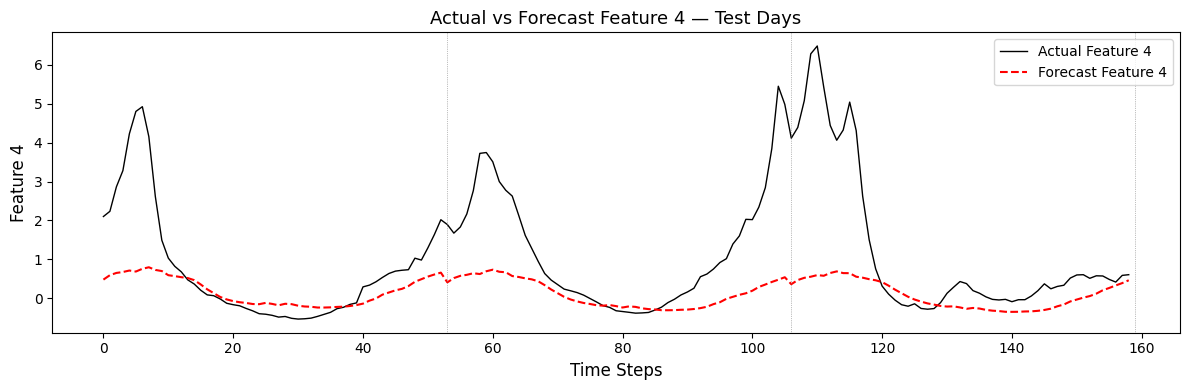

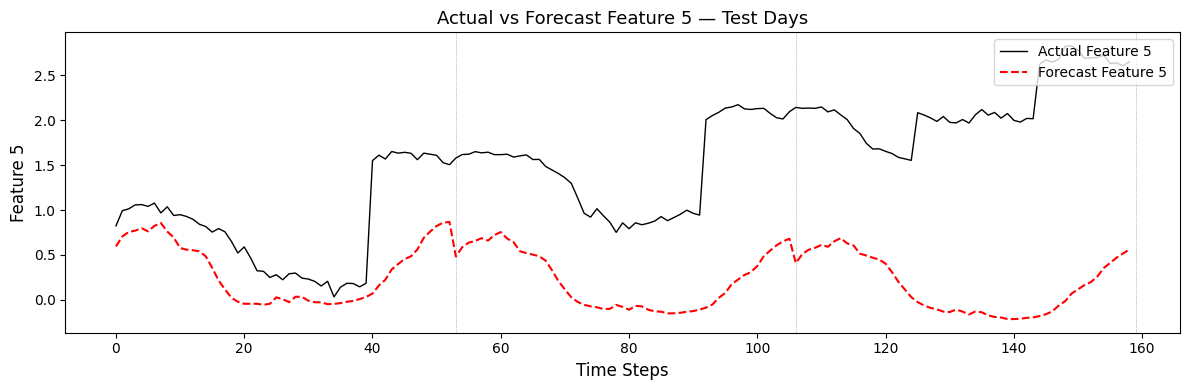

In [ ]:
test_series = tensor[TRAIN_DAYS:].reshape(-1, FEATURES)
forecast_series = forecast_tensor.reshape(-1, FEATURES)
x = np.arange(TEST_DAYS * TIME)

for i in range(FEATURES):
    plt.figure(figsize=(12, 4))
    plt.plot(test_series[:, i], 'k-', lw=1, label=f'Actual Feature {i}')
    plt.plot(forecast_series[:, i], 'r--', lw=1.5, label=f'Forecast Feature {i}')
    for d in range(1, TEST_DAYS + 1):
        plt.axvline(d * TIME, color='gray', ls=':', lw=0.5)
    plt.title(f'Actual vs Forecast Feature {i} — Test Days', fontsize=13)
    plt.xlabel('Time Steps', fontsize=12)
    plt.ylabel(f'Feature {i}', fontsize=12)
    plt.legend(loc='upper right')
    plt.tight_layout()
    plt.show()

In [ ]:
train_series = tensor[:TRAIN_DAYS].reshape(-1, FEATURES)
test_series = tensor[TRAIN_DAYS:].reshape(-1, FEATURES)

train_series.shape, test_series.shape

((795, 6), (159, 6))

In [ ]:
# Accuracy calculation using R squared (R²) metric
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error, root_mean_squared_error

r2_scores = []
mse_scores = []
mae_scores = []
rmse_scores = []

for i in range(FEATURES):
    r2 = r2_score(test_series[:, i], forecast_series[:, i])
    mse = mean_squared_error(test_series[:, i], forecast_series[:, i])
    mae = mean_absolute_error(test_series[:, i], forecast_series[:, i])
    rmse = root_mean_squared_error(test_series[:, i], forecast_series[:, i])
    r2_scores.append(r2)
    mse_scores.append(mse)
    mae_scores.append(mae)
    rmse_scores.append(rmse)
    print(f"Feature {i} R²: {r2:.4f}, MSE: {mse:.4f}, MAE: {mae:.4f}, RMSE: {rmse:.4f}")

print("average R²: {:.4f}, average MSE: {:.4f}, average MAE: {:.4f}, average RMSE: {:.4f}".format(
    np.mean(r2_scores), np.mean(mse_scores), np.mean(mae_scores), np.mean(rmse_scores)))

Feature 0 R²: 0.4509, MSE: 1.0116, MAE: 0.6326, RMSE: 1.0058
Feature 1 R²: 0.4034, MSE: 1.2395, MAE: 0.6998, RMSE: 1.1133
Feature 2 R²: 0.0896, MSE: 2.4644, MAE: 1.0366, RMSE: 1.5698
Feature 3 R²: 0.0999, MSE: 2.4202, MAE: 0.8844, RMSE: 1.5557
Feature 4 R²: -0.0388, MSE: 2.8396, MAE: 1.0313, RMSE: 1.6851
Feature 5 R²: -3.0505, MSE: 2.0932, MAE: 1.2421, RMSE: 1.4468
average R²: -0.3409, average MSE: 2.0114, average MAE: 0.9211, average RMSE: 1.3961
